In [2]:
import os

In [ ]:
import paramiko
from scp import SCPClient
import getpass

# This will change after laptop reboot
host = "192.168.100.78"

# This stays constant
user = "ideapad-flex-5\\hugoa"

# TODO: Delete subfolder after done calculating melspecs (or keep a window of 3-5 subfolders or those that cause errors)

# TODO: Songs subfolder '00' is hard-coded
remote_path = 'D:/100-KULIAH/SKRIPSI/mtg-jamendo-dataset-master/rawdata/00/'
local_path = 'E:/SKRIPSI/prep/code/temp/00/'

ssh = paramiko.SSHClient()
is_error = False
while is_error == False:
    try:
        password = getpass.getpass(prompt='Enter laptop password: ') 

        ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
        ssh.connect(host, username=user, password=password)
        is_error = True
    except:
        is_error = False

dir_command = []
song_filenames = []
try:
    _, stdout, _ = ssh.exec_command(command='dir D:\\100-KULIAH\\SKRIPSI\\mtg-jamendo-dataset-master\\rawdata\\00\\')
    dir_command = stdout.readlines()
    
    for item in dir_command:
        j = item.strip()
        if ".mp3" not in j:
            continue
        else:
            tokens = j.split(' ')
            song_filenames.append(tokens[-1])

    print(f'Amount of song files at reomte is: {len(song_filenames)}')

    file_existing = 0
    file_downloaded = 0
    for sf_name in song_filenames:
        if os.path.exists('./temp/00/' + sf_name):
            file_existing += 1
            continue
        else:
            with SCPClient(ssh.get_transport()) as scp: # type: ignore
                scp.get(remote_path + sf_name, local_path, recursive=True)
                file_downloaded += 1

    print(f'{file_existing} song files already exists at ./temp/00; {file_downloaded} new files were downloaded')
except Exception as e:
    print(f"Error: {e}")
finally:
    ssh.close()

(96, 6243)


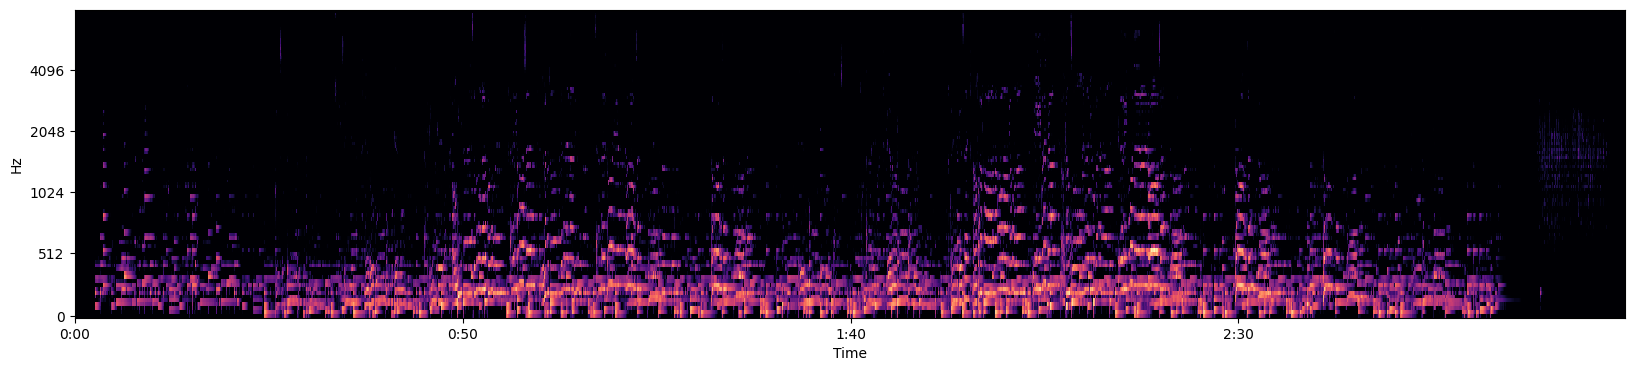

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from pprint import pprint

# INPUT_LEN_SECS = 30
SAMPLE_RATE = 16000
# SAMPLES = INPUT_LEN_SECS * SAMPLE_RATE

y, sr = librosa.load('./temp/00/970600.mp3', sr=SAMPLE_RATE)
# y_midpoint = len(y) // 2
# before_mid = y_midpoint - (SAMPLES // 2)
# after_mid = y_midpoint + (SAMPLES // 2)

# n_fft = 2048; hop_length = 512
s = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=96)
s_db = librosa.amplitude_to_db(s, ref=1e-12)
print(s_db.shape)

plt.figure(figsize=(20,4))
librosa.display.specshow(s_db, sr=sr, x_axis='time', y_axis='mel')
# plt.colorbar()
plt.show()

In [47]:
y2, sr2 = librosa.load('./temp/00/970600.mp3', sr=SAMPLE_RATE)

# -------- old method
# y_midpoint = len(y) // 2
# before_mid = y_midpoint - (SAMPLES // 2)
# after_mid = y_midpoint + (SAMPLES // 2)

# -------- new method
EPSILON = 1e-12
fifteen = SAMPLE_RATE * 30

print(len(y2) // fifteen)

def znorm(col):
    return (col - np.average(col)) / (np.sqrt(np.var(col) + EPSILON))

rawmels = []
melspecs = []

for i in range(len(y2) // fifteen):
    lower = i * fifteen
    upper = (i+1) * fifteen

    if upper > len(y2):
        upper = -1

    si = librosa.feature.melspectrogram(y=y2[lower:upper], sr=sr2, n_mels=96)
    s_dbi = librosa.amplitude_to_db(si, ref=10e-12)
    
    s_dbi_norm = np.apply_along_axis(znorm, 1, s_dbi) # apply across mel bands ie. rows

    rawmels.append(s_dbi)
    melspecs.append(s_dbi_norm)

# debugs
print(len(melspecs))
pprint(melspecs[0])
print(melspecs[0].shape)

# print(rawmels[0])
# print(melspecs[0])

print()

# -------- show all
# n_fft = 2048; hop_length = 512
s2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels=96)
s_db2 = librosa.amplitude_to_db(s2, ref=10e-12)
# print(s_db2.shape)

6
6
array([[-0.40816003, -0.40816003, -0.40816003, ...,  1.9591221 ,
         1.5584598 ,  1.9938053 ],
       [-0.6954863 , -0.6954863 , -0.6954863 , ...,  2.3155432 ,
         2.2291515 ,  2.0502946 ],
       [-1.0365919 , -1.0365919 , -1.0365919 , ...,  1.5689576 ,
         1.5278428 ,  1.3544302 ],
       ...,
       [-0.05532595, -0.05532595, -0.05532595, ..., -0.05532595,
        -0.05532595, -0.05532595],
       [-0.04557817, -0.04557817, -0.04557817, ..., -0.04557817,
        -0.04557817, -0.04557817],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(96, 938), dtype=float32)
(96, 938)



In [48]:
rawmels[0]

array([[ 55.462036,  55.462036,  55.462036, ...,  91.90342 ,  85.73572 ,
         92.437325],
       [ 55.462036,  55.462036,  55.462036, ..., 117.84958 , 116.05957 ,
        112.353714],
       [ 55.462036,  55.462036,  55.462036, ..., 109.44032 , 108.58856 ,
        104.99603 ],
       ...,
       [ 55.462036,  55.462036,  55.462036, ...,  55.462036,  55.462036,
         55.462036],
       [ 55.462036,  55.462036,  55.462036, ...,  55.462036,  55.462036,
         55.462036],
       [ 55.462036,  55.462036,  55.462036, ...,  55.462036,  55.462036,
         55.462036]], shape=(96, 938), dtype=float32)

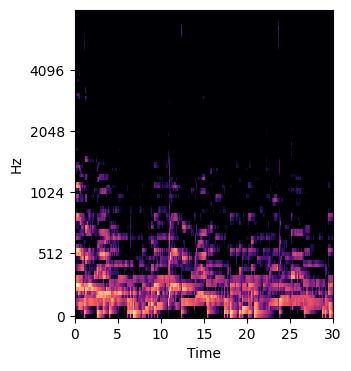

In [49]:
plt.figure(figsize=(20/len(melspecs),4))
librosa.display.specshow(rawmels[-1], sr=sr2, x_axis='time', y_axis='mel')
# plt.colorbar()
plt.show()

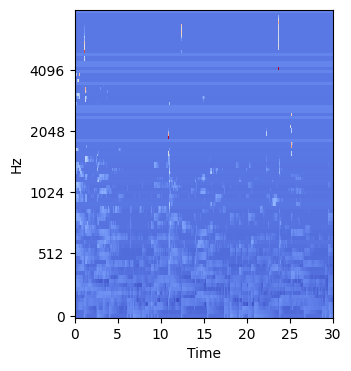

In [50]:
plt.figure(figsize=(20/len(melspecs),4))
librosa.display.specshow(melspecs[-1], sr=sr2, x_axis='time', y_axis='mel')
# plt.colorbar()
plt.show()

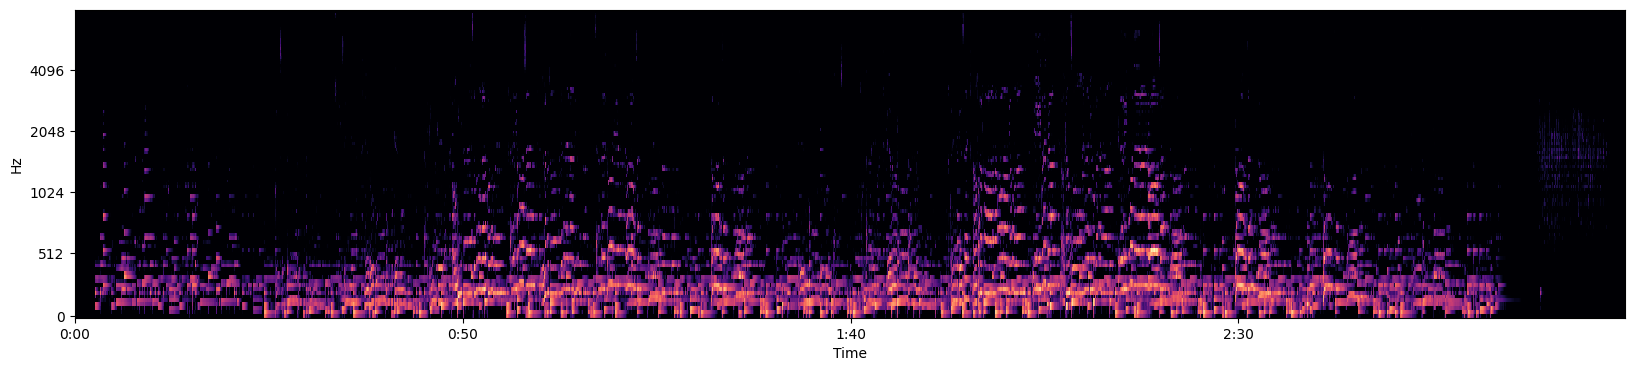

In [51]:
plt.figure(figsize=(20,4))
librosa.display.specshow(s_db2, sr=sr2, x_axis='time', y_axis='mel')
# plt.colorbar()
plt.show()

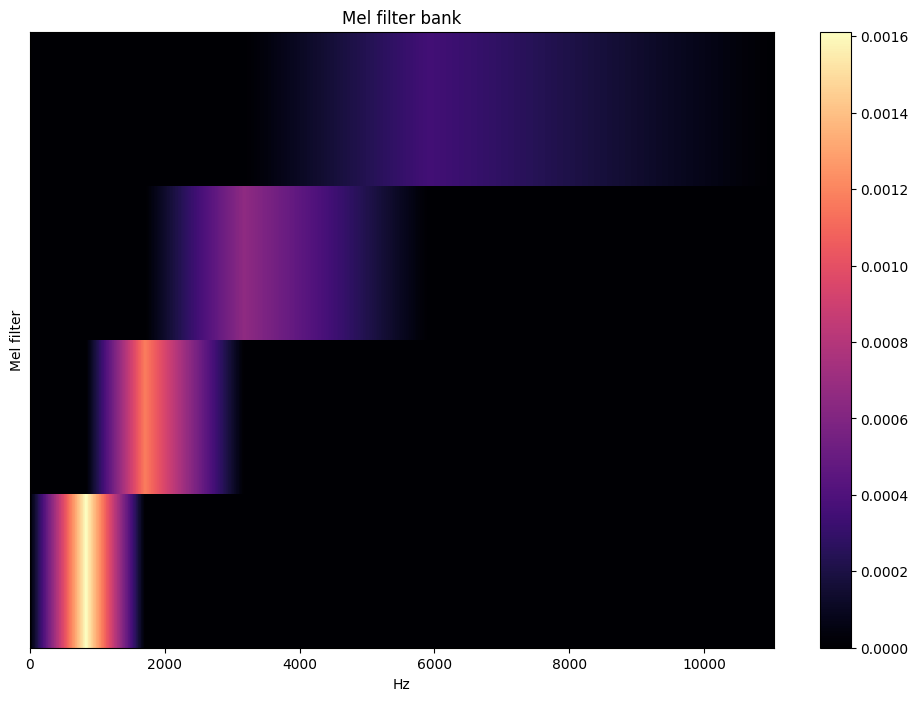

In [13]:
# s_mel = librosa.filters.mel(sr=SAMPLE_RATE, n_mels=96, n_fft=2048)
s_mel = librosa.filters.mel(sr=SAMPLE_RATE, n_mels=4, n_fft=2048)

fig, ax = plt.subplots()
fig.set_size_inches((12,8))
img = librosa.display.specshow(s_mel, x_axis='linear', ax=ax)
ax.set(ylabel='Mel filter', title='Mel filter bank')
fig.colorbar(img, ax=ax)

In [41]:
# Dummy purposes

y, sr = librosa.load('./temp/00/7400.mp3', sr=100)
print(len(y))
print(y[:8])
s = librosa.feature.melspectrogram(y=y, sr=1, n_fft=8, hop_length=4, n_mels=4)
s_db = librosa.amplitude_to_db(np.abs(s), ref=np.max)
print(s.shape)
print(s_db[:8])

14600
[ 0.0096075  -0.00728087 -0.00419529 -0.00208672  0.00062228 -0.00130683
  0.00165333 -0.00127596]
(4, 3651)
[[-55.730824 -68.8602   -80.       ... -80.       -80.       -80.      ]
 [-50.28311  -75.22342  -80.       ... -80.       -80.       -80.      ]
 [-48.062103 -79.91614  -80.       ... -80.       -80.       -80.      ]
 [-47.30985  -76.86029  -75.25905  ... -80.       -80.       -80.      ]]


In [5]:
all_exports = np.empty(shape=(96, 938))
all_exports = []
songfile_order = []

midpoints = []

for song_file in os.scandir('./temp/00'):
    if song_file.is_file():
        y, sr = librosa.load('./temp/00/' + song_file.name, sr=SAMPLE_RATE)
        y_midpoint = len(y) // 2

        before_mid = y_midpoint - (SAMPLES // 2)
        if before_mid < 0:
            before_mid = 0
            after_mid = SAMPLES
        else:
            after_mid = y_midpoint + (SAMPLES // 2)

#         midpoints.append([before_mid, after_mid, after_mid - before_mid])

# from pprint import pprint
# pprint(midpoints)

        s = librosa.feature.melspectrogram(y=y[before_mid:after_mid], sr=sr, n_mels=96)
        s_db = librosa.amplitude_to_db(np.abs(s), ref=np.max)

        songfile_order.append('/00/' + song_file.name)
        all_exports.append(s_db)
        # counter += 1

# print(all_exports)
# print(np.array(all_exports))
all_exports_np = np.array(all_exports)
songfile_order_np = np.array(songfile_order)
print(all_exports_np.shape)
print(songfile_order_np.shape)
np.save('./temp/melspecs/' + '00.npy', all_exports_np)
np.save('./temp/melspecs/' + '00_file_order.npy', songfile_order_np)

(202, 96, 938)
(202,)


/00/1009600.mp3


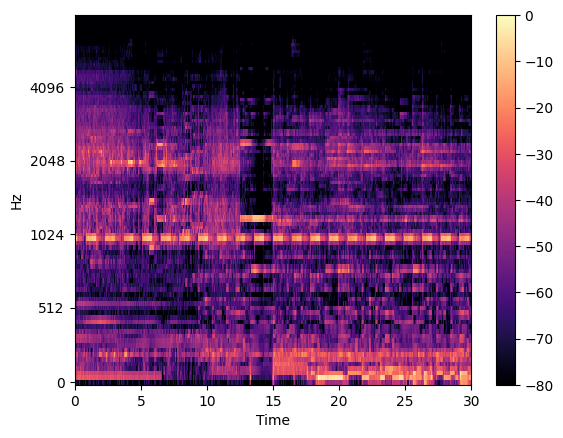

In [6]:
plt.figure()
print(songfile_order[0])
librosa.display.specshow(all_exports[2], sr=sr, x_axis='time', y_axis='mel')
plt.colorbar()
plt.show()